In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns



In [ ]:
##Load Data

df = pd.read_csv(r"D:\Desktop\Python\healthcare_ml_project\heart.csv")


In [5]:
##Basic Overview
print(df.shape)
print(df.head())

(303, 14)
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0      3.5      0   
2   41    0   1       130   204    0        0      172      0      1.4      2   
3   56    1   1       120   236    0        1      178      0      0.8      2   
4   57    0   0       120   354    0        1      163      1      0.6      2   

   ca  thal  target  
0   0     1       1  
1   0     2       1  
2   0     2       1  
3   0     2       1  
4   0     2       1  


In [6]:
##Check for missing values
print(df.isnull().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [7]:
##Basic Stats
print(df.describe())

              age         sex          cp    trestbps        chol         fbs  \
count  303.000000  303.000000  303.000000  303.000000  303.000000  303.000000   
mean    54.366337    0.683168    0.966997  131.623762  246.264026    0.148515   
std      9.082101    0.466011    1.032052   17.538143   51.830751    0.356198   
min     29.000000    0.000000    0.000000   94.000000  126.000000    0.000000   
25%     47.500000    0.000000    0.000000  120.000000  211.000000    0.000000   
50%     55.000000    1.000000    1.000000  130.000000  240.000000    0.000000   
75%     61.000000    1.000000    2.000000  140.000000  274.500000    0.000000   
max     77.000000    1.000000    3.000000  200.000000  564.000000    1.000000   

          restecg     thalach       exang     oldpeak       slope          ca  \
count  303.000000  303.000000  303.000000  303.000000  303.000000  303.000000   
mean     0.528053  149.646865    0.326733    1.039604    1.399340    0.729373   
std      0.525860   22.9051

Data Preprocessing


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

#Features and target
X = df.drop("target",axis=1)
y = df["target"]

In [10]:
#Split Data
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

#Scale Features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [12]:

df = df[df['ca'] < 4] #drop the wrong ca values
df = df[df['thal'] > 0] # drop the wong thal value
print(f'The length of the data now is {len(df)} instead of 303!')

The length of the data now is 296 instead of 303!


In [13]:
df = df.rename(
    columns  = {'cp':'chest_pain_type',
                'trestbps':'resting_blood_pressure',
                'chol':'cholesterol',
                'fbs':'fasting_blood_sugar',
                'restecg' : 'resting_electrocardiogram', 
               'thalach': 'max_heart_rate_achieved', 
               'exang': 'exercise_induced_angina',
               'oldpeak': 'st_depression', 
               'slope': 'st_slope', 
               'ca':'num_major_vessels', 
               'thal': 'thalassemia'
                },errors = "raise"
)

In [14]:
df.dtypes

age                            int64
sex                            int64
chest_pain_type                int64
resting_blood_pressure         int64
cholesterol                    int64
fasting_blood_sugar            int64
resting_electrocardiogram      int64
max_heart_rate_achieved        int64
exercise_induced_angina        int64
st_depression                float64
st_slope                       int64
num_major_vessels              int64
thalassemia                    int64
target                         int64
dtype: object

In [15]:
df.head()

,age,sex,chest_pain_type,resting_blood_pressure,cholesterol,fasting_blood_sugar,resting_electrocardiogram,max_heart_rate_achieved,exercise_induced_angina,st_depression,st_slope,num_major_vessels,thalassemia,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


Train Multiple Models


In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [19]:
models = {
    "LogisticRegression":LogisticRegression(),
    "Random Forest":RandomForestClassifier(n_estimators=100,random_state=42),
    "SVM":SVC(kernel='rbf',probability=True),
    "XGBoost":XGBClassifier(use_label_encoder=False,eval_metric='logloss')
}

In [20]:
for name,model in models.items():
    model.fit(X_train,y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test,y_pred)
    print(f"{name} Accuracy:{acc:.3f}")

LogisticRegression Accuracy:0.803
Random Forest Accuracy:0.836
SVM Accuracy:0.820
XGBoost Accuracy:0.803


Evaluate the best model

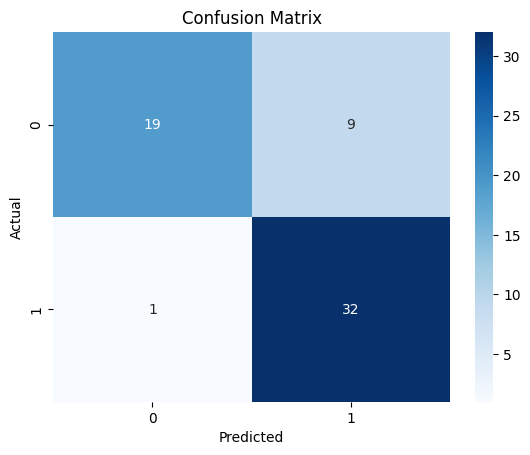

              precision    recall  f1-score   support

           0       0.95      0.68      0.79        28
           1       0.78      0.97      0.86        33

    accuracy                           0.84        61
   macro avg       0.87      0.82      0.83        61
weighted avg       0.86      0.84      0.83        61



In [21]:
best_model = models["Random Forest"]
y_pred = best_model.predict(X_test)
cm = confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(classification_report(y_test,y_pred))

Save Model for Dashboard Integration

In [22]:
import joblib

joblib.dump(best_model,"heart_model.pkl")
joblib.dump(scaler,"heart_scaler.pkl")

['heart_scaler.pkl']

Mini Streamlit App


In [25]:
# app_heart\
import os
print(os.path.exists(r"D:\Desktop\Python\healthcare_ml_project\scaler.pkl"))
print(os.path.exists(r"D:\Desktop\Python\healthcare_ml_project\projectenv\etc\jupyter\heart_scaler.pkl"))


False
True


In [24]:
import joblib
joblib.dump(scaler, r"D:\Desktop\Python\healthcare_ml_project\projectenv\etc\jupyter\scaler.pkl")


['D:\\Desktop\\Python\\healthcare_ml_project\\projectenv\\etc\\jupyter\\scaler.pkl']

In [27]:
import joblib
import pandas as pd
import numpy as np

# Load model and scaler
model = joblib.load(r"D:\Desktop\Python\healthcare_ml_project\projectenv\etc\jupyter\heart_model.pkl")
scaler = joblib.load(r"D:\Desktop\Python\healthcare_ml_project\projectenv\etc\jupyter\heart_scaler.pkl")

# Define columns in the same order as used for training
columns = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
           'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

# Example low-risk input (from previous discussion)
input_values = [35, 0, 0, 115, 180, 0, 0, 170, 0, 0.5, 0, 0, 2]

# Create DataFrame
input_df = pd.DataFrame([input_values], columns=columns)

# Scale input
input_scaled = scaler.transform(input_df)

# Predict
pred = model.predict(input_scaled)
pred  # 0 = No Risk, 1 = High Risk


array([1])

In [29]:
print(input_scaled)



[[-2.11171917 -1.46385011 -0.93599971 -0.9303537  -1.35887824 -0.40430377
  -1.02899151  0.90623686 -0.71589105 -0.47509424 -2.28365678 -0.71469098
  -0.56122273]]


In [31]:
import pandas as pd
import joblib

df = pd.read_csv(r"D:\Desktop\Python\healthcare_ml_project\heart.csv")  # original dataset
no_disease_row = df[df['target'] == 0].iloc[0]  # first no-disease row
features = no_disease_row.drop('target')

print(features)


age          67.0
sex           1.0
cp            0.0
trestbps    160.0
chol        286.0
fbs           0.0
restecg       0.0
thalach     108.0
exang         1.0
oldpeak       1.5
slope         1.0
ca            3.0
thal          2.0
Name: 165, dtype: float64
